# MIL-CREDA vs CREDA — phase one: the ladder

Nine arms over six transfers. Each rung differs from the one below it in a single
thing, so a difference can be attributed to that thing and to nothing else.

| | arm | adaptation | weighting | local | attention |
|---|---|---|---|---|---|
| A | source-only, instances | — | — | — | — |
| B | source-only, bags | — | — | — | learned |
| C | CREDA | yes | no | — | — |
| D | CREDA, full | yes | yes | — | — |
| E | MIL-CREDA global | yes | no | off | learned |
| F | MIL-CREDA global | yes | yes | off | learned |
| G | MIL-CREDA, full | yes | yes | on | learned |
| H1 | MIL-CREDA, full | yes | yes | on | uniform |
| H2 | MIL-CREDA, full | yes | yes | on | random |

CREDA trains on instances, as it was designed to. MIL-CREDA trains on bags. The
comparison happens at the bag because it is the only unit where both decide
without inventing a rule: an instance-unit arm reaches it by averaging the class
distributions of its thirty instances.

Everything else is held identical — backbone, head, material, split, seeds, the
coefficient schedule and the learning-rate decay, both of them CREDA's own.

**Read every table with the header above it.** With fewer than three repetitions
the dispersion is zero, the threshold is zero, and every row declares a winner
from a bare difference. That is stamped rather than hidden, because the pilot has
to exercise the same path the full run will.

To go from the pilot to the full configuration, change two constants in
`src/MIL_CREDA_Benchmark/config.py` — `EPOCHS` and `SEEDS` — and nothing else.

In [1]:
# Bootstrap: locate the repository wherever this is running, and import from it.
# Local, Colab and Kaggle differ only in where the checkout sits.
import os
import sys
from pathlib import Path


def find_repository() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in (os.environ.get("MIL_CREDA_REPO", ""), "/content", "/kaggle/working"):
        if base and Path(base).is_dir():
            candidates.append(Path(base))
            candidates.extend(sorted(Path(base).glob("*")))
    for candidate in candidates:
        if (candidate / "src" / "MIL_CREDA_Benchmark").is_dir():
            return candidate.resolve()
    raise SystemExit(
        "cannot find the repository. Set MIL_CREDA_REPO to the checkout that "
        "holds src/MIL_CREDA_Benchmark, or run this notebook from inside it."
    )


REPOSITORY = find_repository()
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [2]:
import json
import time

from MIL_CREDA_Benchmark import config, harness

device = harness.resolve_device()
reduction = harness.Reduction(device=str(device), environment=harness.environment())

shape = config.sizing()
print(json.dumps(shape, indent=2))
print()
print(harness.header(reduction))
print()
print("environment:", reduction.environment["platform"],
      "| torch", reduction.environment["torch"],
      "| self-hosted" if reduction.environment["selfHosted"] else "| hosted runtime")

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "arms": 9,
  "transfers": 6,
  "seeds": 1,
  "runs": 54,
  "epochs": 3,
  "stepsPerEpoch": 7,
  "imagesPerStep": 300,
  "imagePassesPerRun": 12600,
  "verdictsMeaningful": false
}

setting=trained  backbone=resnet18  bags=100x30  split=64/36  epochs=3  seeds=1  device=mps  revision=research-concept-r16.md
!! 1 repetition(s): the dispersion is zero, so the threshold is zero and every row below declares a winner from a bare difference. These are point estimates, not verdicts.

environment: macOS-26.5.2-arm64-arm-64bit | torch 2.13.0 | self-hosted


In [3]:
# One run, timed, before committing to the whole grid. An estimate of the cost is
# cheaper than the cost, so it happens first.
from MIL_CREDA_Benchmark import bags

material = {role: bags.build(code, config.DATA_CACHE, config.SEEDS[0])
            for role, code in zip(("source", "target"), config.TRANSFERS[0])}
probe = harness.run_one("G", config.TRANSFERS[0], config.SEEDS[0],
                        reduction, device, material)
per_run = probe["seconds"]
full = len(config.ARMS) * len(config.TRANSFERS) * 30 * per_run * 20 / reduction.epochs
print(f"one full arm, {reduction.epochs} epochs: {per_run:.1f}s")
print(f"this grid ({shape['runs']} runs): about {shape['runs'] * per_run / 60:.0f} min")
print(f"at 20 epochs and 30 seeds: about {full / 3600:.0f} h")
del material, probe

one full arm, 3 epochs: 14.1s
this grid (54 runs): about 13 min
at 20 epochs and 30 seeds: about 42 h


In [4]:
started = time.perf_counter()
summary = harness.campaign(reduction, device)
print(f"\ncampaign finished in {(time.perf_counter() - started) / 60:.1f} min")

   A M->U seed 0: target 0.778  source 1.000  4.8s


   B M->U seed 0: target 0.472  source 0.944  4.8s


   C M->U seed 0: target 0.833  source 1.000  10.6s


   D M->U seed 0: target 0.722  source 1.000  8.4s


   E M->U seed 0: target 0.556  source 0.972  12.1s


...

   E S->U seed 0: target 0.361  source 0.333  12.2s


   F S->U seed 0: target 0.278  source 0.333  12.2s


   G S->U seed 0: target 0.250  source 0.361  13.1s


  H1 S->U seed 0: target 0.583  source 0.389  14.3s


  H2 S->U seed 0: target 0.167  source 0.194  12.9s

campaign finished in 9.5 min


In [5]:
# The panorama. No single transfer of this size resolves a small difference, so
# what carries the reading is agreement across the six.
print(harness.header(reduction))
print()
print(harness.render_panorama(summary))

setting=trained  backbone=resnet18  bags=100x30  split=64/36  epochs=3  seeds=1  device=mps  revision=research-concept-r16.md
!! 1 repetition(s): the dispersion is zero, so the threshold is zero and every row below declares a winner from a bare difference. These are point estimates, not verdicts.

panorama over 6 transfers, 1 seed(s) each

rung    metric              difference     leans  reading
A->B    targetAccuracy    -0.1435 ± 0.070     1/6    what the bag representation buys, with adaptation off
A->B    sourceAccuracy    -0.0648 ± 0.026     0/6    what the bag representation buys, with adaptation off
A->C    targetAccuracy    +0.0185 ± 0.009     3/6    what CREDA's alignment buys, unweighted
A->C    sourceAccuracy    +0.0000 ± 0.000     0/6    what CREDA's alignment buys, unweighted
C->D    targetAccuracy    -0.0694 ± 0.036     1/6    what confidence weighting buys in CREDA
C->D    sourceAccuracy    -0.0046 ± 0.005     0/6    what confidence weighting buys in CREDA
B->E    target

In [6]:
for transfer in summary["grid"]:
    print(harness.render_transfer(summary, transfer))
    print()

[M->U]
setting=trained  backbone=resnet18  data=M->U  seeds=1  revision=research-concept-r16.md

dimension                                 baseline             new  winner
A->B targetAccuracy                     0.7778 ± 0      0.4722 ± 0  baseline
A->B sourceAccuracy                          1 ± 0      0.9444 ± 0  baseline
A->C targetAccuracy                     0.7778 ± 0      0.8333 ± 0  new
A->C sourceAccuracy                          1 ± 0           1 ± 0  indistinguishable
                                                                    (the means are closer than their combined standard error)
C->D targetAccuracy                     0.8333 ± 0      0.7222 ± 0  baseline
C->D sourceAccuracy                          1 ± 0           1 ± 0  indistinguishable
                                                                    (the means are closer than their combined standard error)
B->E targetAccuracy                     0.4722 ± 0      0.5556 ± 0  new
B->E sourceAccuracy          

In [7]:
# The scale of each adaptation term, which is what the normalization of Section 5
# is about. Two things are read here and neither replaces the other:
#
#   share  — did the coefficient leave the term anything to say, or is it a
#            rounding error against the supervised loss?
#   range  — does the term stay on one scale? MIL-CREDA's is in [0, 1] by
#            construction; CREDA's is bounded only by ln n, a window that widens
#            with the bags a class contributes.
#
# The spread across transfers is the sharper test: a common scale means the same
# term lands in the same range whichever pair of domains it is measuring.
collected = {}
with (config.RESULTS / "runs.jsonl").open(encoding="utf-8") as handle:
    for line in handle:
        run = json.loads(line)
        entry = collected.setdefault(run["arm"], {"sup": [], "adapt": [], "contrib": [],
                                                  "byTransfer": {}})
        for point in run["curve"]:
            entry["sup"].append(point["supervised"])
            entry["adapt"].append(point["adaptation"])
            entry["contrib"].append(abs(point["contribution"]))
            entry["byTransfer"].setdefault(run["transfer"], []).append(point["adaptation"])

mean = lambda xs: sum(xs) / len(xs)
print(f"{'arm':<4}{'supervised':>12}{'adaptation':>12}{'share':>11}"
      f"{'min':>10}{'max':>10}{'width':>9}{'width across transfers':>24}")
for arm in [a["id"] for a in config.ARMS]:
    if arm not in collected:
        continue
    entry = collected[arm]
    supervised, contribution = mean(entry["sup"]), mean(entry["contrib"])
    low, high = min(entry["adapt"]), max(entry["adapt"])
    per_transfer = [max(v) - min(v) for v in entry["byTransfer"].values()]
    drift = (max(per_transfer) - min(per_transfer)) if per_transfer else 0.0
    print(f"{arm:<4}{supervised:>12.4f}{mean(entry['adapt']):>12.4f}"
          f"{contribution / supervised:>11.2e}{low:>10.3f}{high:>10.3f}"
          f"{high - low:>9.3f}{drift:>24.3f}")

arm   supervised  adaptation      share       min       max    width  width across transfers
A         0.6795      0.0000   0.00e+00     0.000     0.000    0.000                   0.000
B         0.5067      0.0000   0.00e+00     0.000     0.000    0.000                   0.000
C         0.6810      0.0466   4.47e-02    -0.001     0.102    0.103                   0.049
D         0.7248     -0.4795   3.77e-01    -1.115    -0.014    1.101                   0.587
E         0.5212      0.3559   4.56e-01     0.118     0.676    0.557                   0.220
F         0.5146      0.2822   3.79e-01     0.078     0.527    0.449                   0.162
G         0.5216      0.3609   4.71e-01     0.090     0.735    0.645                   0.259
H1        0.2834      0.1818   4.14e-01     0.076     0.315    0.238                   0.047
H2        1.1037      0.8146   5.14e-01     0.092     1.677    1.585                   0.679


MIL-CREDA/Results/Benchmark/curves/adaptation.png


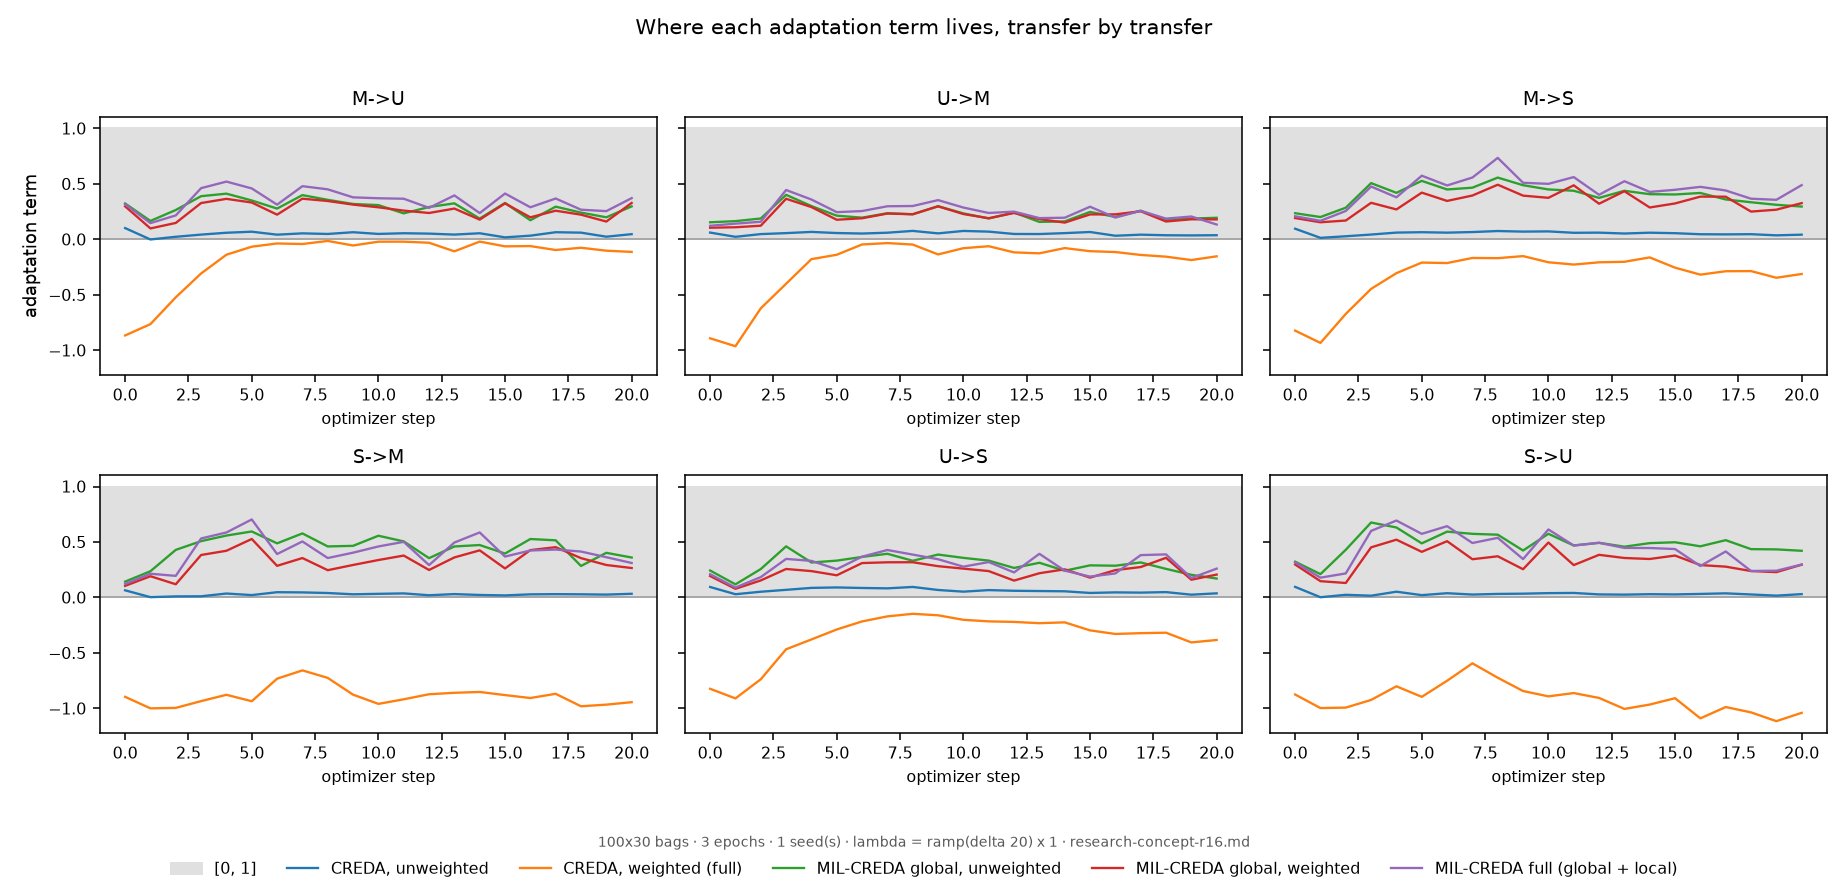

MIL-CREDA/Results/Benchmark/curves/supervised.png


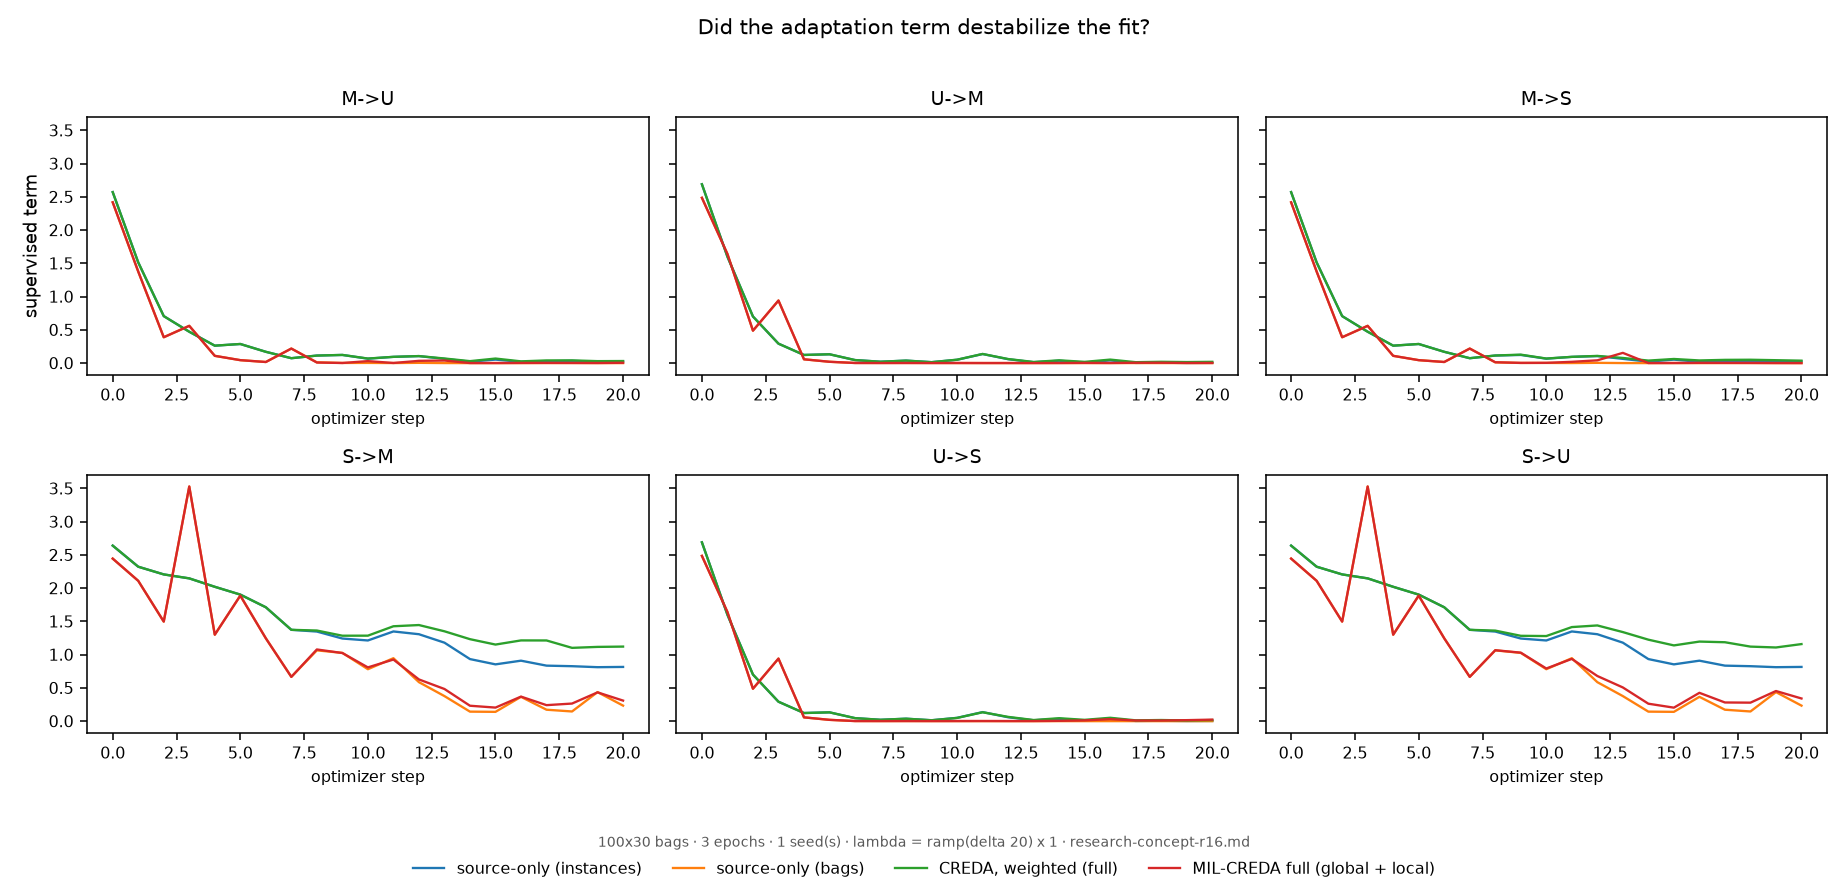

In [8]:
# The same claim as the table above, drawn. The shaded band is [0, 1]: the
# normalization puts MIL-CREDA's terms on exactly that interval and the prior work's
# score has no such bound, so whether a curve stays inside it — and whether it sits in
# the same part of it from one transfer to the next — is the claim, not a decoration.
#
# The second figure is the supervised term beside it. Read alone, an adaptation curve
# can look well-behaved while the classification it shares an objective with comes
# apart underneath.
from IPython.display import Image, display

from MIL_CREDA_Benchmark import figures

adaptation = figures.adaptation_curves(config.RESULTS / "curves" / "adaptation.png")
supervised = figures.supervised_curves(config.RESULTS / "curves" / "supervised.png")
for path in (adaptation, supervised):
    print(path.relative_to(REPOSITORY))
    display(Image(filename=str(path)))

In [9]:
report = "\n\n".join([
    harness.header(reduction),
    harness.render_panorama(summary),
    *(harness.render_transfer(summary, transfer) for transfer in summary["grid"]),
])
(config.RESULTS / "report.txt").write_text(report, encoding="utf-8")
print("written:")
for path in sorted(config.RESULTS.iterdir()):
    print(" ", path.relative_to(REPOSITORY), f"{path.stat().st_size / 1024:.0f} KB")
print("checkpoints kept:", sum(len(v) for v in summary["checkpoints"].values()))

written:
  MIL-CREDA/Results/Benchmark/curves 0 KB
  MIL-CREDA/Results/Benchmark/latent 1 KB
  MIL-CREDA/Results/Benchmark/latent.json 16 KB
  MIL-CREDA/Results/Benchmark/report.txt 20 KB
  MIL-CREDA/Results/Benchmark/runs.jsonl 173 KB
  MIL-CREDA/Results/Benchmark/summary.json 293 KB
checkpoints kept: 24
